We expanded our first experiment to 20 US companies from seven sectors. The question is still the same: can a model help us choose better weights for Value, Profitability and Momentum? We now compare ten models instead of five. The original three-stock notebook is kept separately.

We use Ridge, Elastic Net, K-Nearest Neighbours, Support Vector Regression, Random Forest, Extra Trees, XGBoost, MLP, LSTM and CNN. Each predicts the next four-week return of three factor portfolios. A positive forecast gives an Up signal. A zero or negative forecast gives a Down signal. These are portfolio forecasts, not separate predictions for each company.

The saved prices and annual income statements come from Eulerpool. The files cover January 2014 to September 2026, with earlier financial statements where available. Apple, Microsoft and Amazon use the snapshots downloaded on 6 October 2026. The other companies were downloaded on 8 October. The notebook runs from the saved files and does not need an API key. Its packages are in requirements-research.txt in the project root.

We chose this group before running the models, to include familiar companies from several sectors. It is still a small group selected from companies trading today, so it has survivorship and selection bias. It is not a sample of the whole US market.

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from IPython.display import display
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import TransformedTargetRegressor
from sklearn.exceptions import ConvergenceWarning
from xgboost import XGBRegressor

ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'inputs/us_stock_expanded').is_dir())
INPUTS = ROOT / 'inputs/us_stock_expanded'
RESULTS = ROOT / 'results/us_stock_expanded'
RESULTS.mkdir(parents=True, exist_ok=True)
STOCKS = ['AAPL', 'MSFT', 'NVDA', 'ORCL', 'AMZN', 'HD', 'MCD', 'WMT', 'COST', 'PG', 'KO', 'JNJ', 'PFE', 'MRK', 'XOM', 'CVX', 'CAT', 'HON', 'NEE', 'DUK']
FACTORS = ['Value', 'Profitability', 'Momentum']
START = pd.Timestamp('2016-10-01')
END = pd.Timestamp('2026-09-30')
TEST_START = pd.Timestamp('2023-01-06')
INITIAL_VALUE = 100000.0
TRADING_COST = 0.001
TOP_STOCKS = 5
LOOKBACK = 8
EPOCHS = 80
torch.set_num_threads(1)
torch.use_deterministic_algorithms(True)
pd.options.display.float_format = '{:,.4f}'.format
plt.rcParams.update({'figure.figsize': (11, 5), 'axes.spines.top': False, 'axes.spines.right': False})
display(pd.read_csv(INPUTS / 'stocks.csv')[['ticker', 'name', 'sector', 'currency']])

,ticker,name,sector,currency
0,AAPL,Apple Inc,Technology,USD
1,MSFT,Microsoft Corp,Technology,USD
2,NVDA,NVIDIA Corp,Technology,USD
3,ORCL,Oracle Corp,Technology,USD
4,AMZN,Amazon.com Inc,Consumer discretionary,USD
5,HD,Home Depot Inc,Consumer discretionary,USD
6,MCD,McDonald's Corp,Consumer discretionary,USD
7,WMT,Walmart Inc,Consumer staples,USD
8,COST,Costco Wholesale Corp,Consumer staples,USD
9,PG,Procter & Gamble Co,Consumer staples,USD


We use dates where all 20 companies have an observed closing price. We do not fill missing prices. When a stock has two different closing prices on the same date, we leave out that date. Identical copies are reduced to one row. This gives every strategy the same valuation dates, although gaps can hide a short-lived fall in value.

We leave out forecast financial statements and incomplete rows. A statement can first be used six months after its financial year ends, and we stop using it after 18 months. This is a reporting-delay rule. It does not turn revised financial data into a verified point-in-time dataset.

In [2]:
price_parts = []
price_checks = []
conflicting_rows = []
for stock in STOCKS:
    frame = pd.read_csv(INPUTS / f'{stock}_prices.csv', parse_dates=['date'])
    if frame.close.isna().any() or frame.close.le(0).any() or not np.isfinite(frame.close).all():
        raise ValueError(f'Check the price data for {stock}.')
    frame = frame.loc[(frame.date <= END) & (frame.date.dt.dayofweek < 5)]
    price_counts = frame.groupby('date').close.nunique()
    conflicts = price_counts.index[price_counts > 1]
    conflicting_rows.append(frame.loc[frame.date.isin(conflicts)].assign(stock=stock))
    frame = frame.loc[~frame.date.isin(conflicts)].drop_duplicates('date')
    series = frame.set_index('date').close.sort_index().rename(stock)
    price_parts.append(series)
    price_checks.append({'Stock': stock, 'Rows': len(series), 'Conflicting dates excluded': len(conflicts), 'First date': series.index.min(), 'Last date': series.index.max()})
all_prices = pd.concat(price_parts, axis=1, sort=True).sort_index()
prices = all_prices.dropna()
price_checks = pd.DataFrame(price_checks)
pd.concat(conflicting_rows, ignore_index=True).to_csv(RESULTS / 'conflicting_prices.csv', index=False)
price_checks.to_csv(RESULTS / 'price_checks.csv', index=False)
display(price_checks)
print(f'{len(prices)} common daily observations; {len(all_prices) - len(prices)} incomplete dates excluded.')
print(f'Largest gap between common price dates: {prices.index.to_series().diff().dt.days.max():.0f} days.')

,Stock,Rows,Conflicting dates excluded,First date,Last date
0,AAPL,3163,37,2014-01-02,2026-09-30
1,MSFT,3200,2,2014-01-02,2026-09-30
2,NVDA,3163,37,2014-01-02,2026-09-30
3,ORCL,3202,0,2014-01-02,2026-09-30
4,AMZN,3160,32,2014-01-02,2026-09-30
5,HD,3176,24,2014-01-02,2026-09-30
6,MCD,3175,26,2014-01-02,2026-09-30
7,WMT,3164,36,2014-01-02,2026-09-30
8,COST,3168,31,2014-01-02,2026-09-30
9,PG,3171,29,2014-01-02,2026-09-30


3134 common daily observations; 69 incomplete dates excluded.
Largest gap between common price dates: 13 days.


In [3]:
statements = {}
financial_checks = []
for stock in STOCKS:
    income = pd.read_csv(INPUTS / f'{stock}_income.csv')
    actual = income.period.str.fullmatch(r'\d{4}-\d{2}-\d{2}')
    frame = income.loc[actual, ['period', 'netIncome', 'revenue', 'shares']].copy()
    frame['period'] = pd.to_datetime(frame.period)
    if frame.period.duplicated().any():
        raise ValueError(f'Check the annual statement dates for {stock}.')
    before = len(frame)
    frame = frame.dropna().sort_values('period')
    frame['available_date'] = frame.period + pd.DateOffset(months=6)
    frame = frame.loc[(frame.shares > 0) & (frame.revenue > 0)]
    statements[stock] = frame
    financial_checks.append({'Stock': stock, 'Forecast rows excluded': int((~actual).sum()), 'Incomplete or invalid rows excluded': before - len(frame), 'Complete annual rows': len(frame)})
financial_checks = pd.DataFrame(financial_checks)
display(financial_checks)
financial_checks.to_csv(RESULTS / 'financial_checks.csv', index=False)

,Stock,Forecast rows excluded,Incomplete or invalid rows excluded,Complete annual rows
0,AAPL,0,0,43
1,MSFT,0,0,44
2,NVDA,0,2,31
3,ORCL,0,0,43
4,AMZN,0,1,30
5,HD,0,0,44
6,MCD,0,0,43
7,WMT,0,0,43
8,COST,0,0,41
9,PG,0,0,44


Each factor portfolio holds its five highest-ranked companies, with 20% in each. Value uses annual net income divided by estimated market value. Profitability uses annual net income divided by revenue. Momentum uses the price return from 52 weeks ago to four weeks ago, divided by annualised volatility over the last 52 weeks.

Market value is estimated from the provider's adjusted share price and lagged annual share count. Financial amounts and shares are both in millions. We keep the provider's split basis rather than adjusting the same shares twice. These are practical factor measures for this experiment. Earnings yield and net profit margin differ from the EBIT-based measures in the earlier proposal, and they are not the standard Fama-French factor returns.

We calculate scores on Fridays. The trade takes place at the next closing price recorded for every company, provided it is within seven calendar days. Each position is held until the next scheduled trade four weeks later. Factor rankings use raw company scores, so sector differences can affect which companies are selected.

In [4]:
weekly = prices.resample('W-FRI').last()
weekly = weekly.loc[weekly.index <= END]
weekly_returns = weekly.pct_change(fill_method=None)
volatility = weekly_returns.rolling(52).std() * np.sqrt(52)
momentum = weekly.shift(4) / weekly.shift(52) - 1
features = []
bucket_weights = {}
score_rows = []
execution_dates = {}

for i in range(52, len(weekly)):
    signal = weekly.index[i]
    if signal < START:
        continue
    position = prices.index.searchsorted(signal, side='right')
    if position >= len(prices):
        continue
    if (prices.index[position] - signal).days > 7:
        continue
    scores = pd.DataFrame(index=STOCKS, columns=FACTORS, dtype=float)
    rows = []
    for stock in STOCKS:
        available = statements[stock].loc[statements[stock].available_date <= signal]
        if available.empty:
            continue
        row = available.iloc[-1]
        if signal > row.period + pd.DateOffset(months=18):
            continue
        estimated_cap = weekly.loc[signal, stock] * row.shares
        if estimated_cap <= 0:
            continue
        scores.loc[stock] = [row.netIncome / estimated_cap, row.netIncome / row.revenue, momentum.loc[signal, stock] / volatility.loc[signal, stock]]
        rows.append({'signal': signal, 'stock': stock, 'statement_period': row.period, 'available_date': row.available_date, 'estimated_market_value_million_usd': estimated_cap})
    if scores.isna().any().any() or not np.isfinite(scores.to_numpy()).all():
        continue
    weights = pd.DataFrame(0.0, index=STOCKS, columns=FACTORS)
    values = {'signal': signal}
    basket_returns = pd.DataFrame(index=weekly_returns.iloc[i-12:i+1].index)
    for factor in FACTORS:
        selected = scores[factor].sort_values(ascending=False, kind='stable').index[:TOP_STOCKS]
        weights.loc[selected, factor] = 1 / TOP_STOCKS
        for weeks in [1, 4, 13]:
            past_return = weekly.iloc[i] / weekly.iloc[i-weeks] - 1
            values[f'{factor}_{weeks}w'] = past_return.dot(weights[factor])
        basket_returns[factor] = weekly_returns.iloc[i-12:i+1].dot(weights[factor])
        values[f'{factor}_volatility'] = basket_returns[factor].std() * np.sqrt(52)
    correlation = basket_returns.corr().to_numpy()
    values['factor_correlation'] = correlation[np.triu_indices(3, 1)].mean()
    features.append(values)
    bucket_weights[signal] = weights
    execution_dates[signal] = prices.index[position]
    for row in rows:
        row.update(scores.loc[row['stock']].to_dict())
        score_rows.append(row)

X = pd.DataFrame(features).set_index('signal').sort_index()
score_history = pd.DataFrame(score_rows)
score_history.to_csv(RESULTS / 'factor_scores.csv', index=False)
display(score_history.loc[score_history.signal == X.index[-1]].set_index('stock')[['statement_period'] + FACTORS])

,statement_period,Value,Profitability,Momentum
stock,,,,
AAPL,2025-09-30,0.0280,0.2692,1.0369
MSFT,2025-06-30,0.0323,0.3615,0.1763
NVDA,2025-01-31,0.0148,0.5585,2.1430
ORCL,2025-05-31,0.0243,0.2168,0.2979
AMZN,2024-12-31,0.0220,0.0929,0.5539
HD,2025-01-31,0.0426,0.0928,-0.2386
MCD,2024-12-31,0.0367,0.3172,0.0349
WMT,2025-01-31,0.0190,0.0285,1.5466
COST,2025-08-31,0.0182,0.0294,0.0378


The inputs describe the current factor portfolios. We use their stocks' one-, four- and 13-week returns, 13-week volatility, and the average correlation between the three portfolios. These are summaries of the current holdings' past prices, not returns from a factor strategy that kept rebalancing in the past.

All ten models receive eight consecutive weeks of the same inputs. LSTM and CNN read them as a sequence. The other models read the same values as columns. More companies give us more possible holdings, but they do not give us 20 independent training observations each week. We still predict three related factor portfolios.

The test starts in January 2023 on a fixed four-week schedule. Training only uses outcomes that finished before the new signal date. We fit any scaling on those training rows only. If a required test window is missing, we stop the continuous comparison rather than join together disconnected holding periods. We have already explored part of this period in the first notebook, so this is a development comparison, not a new untouched final test.

In [5]:
Y = pd.DataFrame(index=X.index, columns=FACTORS, dtype=float)
label_end = pd.Series(pd.NaT, index=X.index, dtype='datetime64[ns]')
for signal in X.index:
    later_signal = signal + pd.Timedelta(weeks=4)
    if later_signal not in execution_dates:
        continue
    entry = execution_dates[signal]
    exit_date = execution_dates[later_signal]
    stock_return = prices.loc[exit_date] / prices.loc[entry] - 1
    Y.loc[signal] = stock_return.dot(bucket_weights[signal])
    label_end.loc[signal] = exit_date

sequence_dates = []
sequence_values = []
for signal in X.index:
    window = pd.date_range(end=signal, periods=LOOKBACK, freq='W-FRI')
    if window.isin(X.index).all() and np.isfinite(X.loc[window].to_numpy()).all():
        sequence_dates.append(signal)
        sequence_values.append(X.loc[window].to_numpy())
sequence_dates = pd.DatetimeIndex(sequence_dates)
sequences = np.stack(sequence_values)
sequence_y = Y.loc[sequence_dates]
sequence_end = label_end.loc[sequence_dates]
scheduled_dates = pd.date_range(TEST_START, END, freq='4W-FRI')
test_dates = []
for signal in scheduled_dates:
    if signal not in sequence_dates or Y.loc[signal].isna().any():
        break
    if test_dates and label_end.loc[test_dates[-1]] != execution_dates[signal]:
        raise ValueError('The holding periods do not connect.')
    test_dates.append(signal)
test_dates = pd.DatetimeIndex(test_dates)
if len(test_dates) < 12:
    raise ValueError('Not enough consecutive test periods.')
schedule = pd.DataFrame({'signal': test_dates, 'entry': [execution_dates[d] for d in test_dates], 'exit': label_end.loc[test_dates].to_numpy()})
schedule.to_csv(RESULTS / 'test_schedule.csv', index=False)
X.to_csv(RESULTS / 'model_inputs.csv')
Y.to_csv(RESULTS / 'model_targets.csv')
print(f'{len(sequences)} valid eight-week sequences and {len(test_dates)} completed test periods.')
print(f'Holding dates: {schedule.entry.iloc[0].date()} to {schedule.exit.iloc[-1].date()}.')
print(f'Last usable signal: {sequence_dates[-1].date()}.')

491 valid eight-week sequences and 42 completed test periods.
Holding dates: 2023-01-09 to 2026-03-30.
Last usable signal: 2026-04-17.


We keep the model settings fixed for this run. Ridge and Elastic Net provide linear comparisons. K-Nearest Neighbours and Support Vector Regression give us two other ways to connect the inputs with later returns. Random Forest, Extra Trees and XGBoost use trees. MLP, LSTM and CNN are small neural networks.

The LSTM has eight hidden units. The CNN has eight filters, a three-week kernel and average pooling. Both train for 80 epochs using Adam. We also include a forecast based on each factor portfolio's average training return. It uses exactly the same training dates as the learned models. No model is tuned using the test results.

In [6]:
def scaled(model):
    return TransformedTargetRegressor(regressor=make_pipeline(StandardScaler(), model), transformer=StandardScaler())

def make_models():
    return {
        'Ridge': scaled(Ridge(alpha=10.0)),
        'Elastic Net': scaled(MultiOutputRegressor(ElasticNet(alpha=0.02, l1_ratio=0.5, max_iter=10000, random_state=42))),
        'KNN': scaled(KNeighborsRegressor(n_neighbors=20)),
        'SVR': scaled(MultiOutputRegressor(SVR(C=1.0, epsilon=0.1))),
        'Random Forest': RandomForestRegressor(n_estimators=150, max_depth=4, min_samples_leaf=12, random_state=42, n_jobs=2),
        'Extra Trees': ExtraTreesRegressor(n_estimators=150, max_depth=4, min_samples_leaf=12, random_state=42, n_jobs=2),
        'XGBoost': MultiOutputRegressor(XGBRegressor(n_estimators=120, max_depth=2, learning_rate=0.03, subsample=0.8, colsample_bytree=0.9, reg_lambda=5, objective='reg:squarederror', random_state=42, n_jobs=2)),
        'MLP': scaled(MLPRegressor(hidden_layer_sizes=(12,), solver='lbfgs', alpha=5.0, max_iter=1500, max_fun=30000, tol=0.0001, random_state=42))
    }

In [7]:
class SmallLSTM(nn.Module):
    def __init__(self, features):
        super().__init__()
        self.lstm = nn.LSTM(features, 8, batch_first=True)
        self.output = nn.Linear(8, 3)

    def forward(self, values):
        history, state = self.lstm(values)
        return self.output(history[:, -1])

class SmallCNN(nn.Module):
    def __init__(self, features):
        super().__init__()
        self.layers = nn.Sequential(nn.Conv1d(features, 8, 3), nn.ReLU(), nn.AdaptiveAvgPool1d(1), nn.Flatten(), nn.Linear(8, 3))

    def forward(self, values):
        return self.layers(values.transpose(1, 2))

def fit_deep(model_class, train_x, train_y, test_x):
    torch.manual_seed(42)
    feature_scaler = StandardScaler().fit(train_x.reshape(-1, train_x.shape[-1]))
    target_scaler = StandardScaler().fit(train_y)
    scaled_train = feature_scaler.transform(train_x.reshape(-1, train_x.shape[-1])).reshape(train_x.shape)
    scaled_test = feature_scaler.transform(test_x.reshape(-1, test_x.shape[-1])).reshape(test_x.shape)
    inputs = torch.tensor(scaled_train, dtype=torch.float32)
    targets = torch.tensor(target_scaler.transform(train_y), dtype=torch.float32)
    model = model_class(train_x.shape[-1])
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=0.01)
    loss_function = nn.MSELoss()
    losses = []
    model.train()
    for epoch in range(EPOCHS):
        optimizer.zero_grad()
        loss = loss_function(model(inputs), targets)
        if not torch.isfinite(loss):
            raise ValueError('The model loss is not finite.')
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    model.eval()
    with torch.no_grad():
        output = model(torch.tensor(scaled_test, dtype=torch.float32)).numpy()
    return target_scaler.inverse_transform(output)[0], losses

In [8]:
prediction_rows = []
training_rows = []
warning_rows = []
loss_rows = []
run_dates = test_dates.union(pd.DatetimeIndex([sequence_dates[-1]]))
for number, signal in enumerate(run_dates, start=1):
    eligible = (sequence_dates < signal) & sequence_end.lt(signal) & sequence_y.notna().all(axis=1)
    train_x = sequences[eligible.to_numpy()]
    train_y = sequence_y.loc[eligible].to_numpy()
    test_x = sequences[[sequence_dates.get_loc(signal)]]
    if len(train_x) < 156:
        raise ValueError('At least three years of training observations are required.')
    training_rows.append({'signal': signal, 'training_sequences': len(train_x), 'latest_training_exit': sequence_end.loc[eligible].max()})
    forecasts = {'Historical mean': train_y.mean(axis=0)}
    for name, model in make_models().items():
        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter('always', ConvergenceWarning)
            model.fit(train_x.reshape(len(train_x), -1), train_y)
        warning_rows.extend({'signal': signal, 'model': name, 'warning': str(item.message)} for item in caught)
        forecasts[name] = np.asarray(model.predict(test_x.reshape(1, -1))).reshape(-1)
    for name, model_class in [('LSTM', SmallLSTM), ('CNN', SmallCNN)]:
        forecasts[name], losses = fit_deep(model_class, train_x, train_y, test_x)
        loss_rows.extend({'signal': signal, 'model': name, 'epoch': epoch+1, 'training_mse_scaled': loss} for epoch, loss in enumerate(losses))
    for name, values in forecasts.items():
        for factor, value in zip(FACTORS, values):
            prediction_rows.append({'signal': signal, 'entry': execution_dates[signal], 'exit': label_end.loc[signal], 'model': name, 'factor': factor, 'predicted_return': value, 'actual_return': Y.loc[signal, factor], 'trend': 'Up' if value > 0 else 'Down', 'completed_test': signal in test_dates})
    if number % 10 == 0 or number == len(run_dates):
        print(f'Finished {number} of {len(run_dates)} forecast dates.')

predictions = pd.DataFrame(prediction_rows)
predictions.to_csv(RESULTS / 'predictions.csv', index=False)
pd.DataFrame(training_rows).to_csv(RESULTS / 'training_dates.csv', index=False)
pd.DataFrame(loss_rows).to_csv(RESULTS / 'training_losses.csv', index=False)
pd.DataFrame(warning_rows, columns=['signal', 'model', 'warning']).to_csv(RESULTS / 'fit_warnings.csv', index=False)
print(f'Fitting warnings: {len(warning_rows)}.')

Finished 10 of 43 forecast dates.


Finished 20 of 43 forecast dates.


Finished 30 of 43 forecast dates.


Finished 40 of 43 forecast dates.


Finished 43 of 43 forecast dates.
Fitting warnings: 0.


Direction accuracy alone can be misleading when prices rise more often than they fall. We also show the share of Up predictions and how many falling periods each model recognised. Balanced accuracy gives rising and falling outcomes equal importance. Return errors are measured in percentage points.

The Always Up row is a direction-only comparison. It does not forecast a return or create another portfolio. The other rows use their predicted returns to get the direction. Factor portfolios share companies, and weekly training targets overlap, so these forecasts are not independent observations.

In [9]:
def direction_metrics(actual, predicted):
    actual_up = np.asarray(actual) > 0
    predicted_up = np.asarray(predicted) > 0
    up_recall = predicted_up[actual_up].mean() if actual_up.any() else np.nan
    down_recall = (~predicted_up[~actual_up]).mean() if (~actual_up).any() else np.nan
    return {
        'Direction accuracy %': 100 * (actual_up == predicted_up).mean(),
        'Balanced accuracy %': 50 * (up_recall + down_recall),
        'Actual Up %': 100 * actual_up.mean(),
        'Predicted Up %': 100 * predicted_up.mean(),
        'Down recall %': 100 * down_recall,
        'Forecasts': len(actual_up)
    }

completed = predictions.loc[predictions.completed_test]
accuracy_rows = []
factor_accuracy_rows = []
for name, group in completed.groupby('model', sort=False):
    accuracy_rows.append({'Model': name, **direction_metrics(group.actual_return, group.predicted_return), 'MAE percentage points': 100 * (group.actual_return - group.predicted_return).abs().mean()})
    for factor, part in group.groupby('factor', sort=False):
        factor_accuracy_rows.append({'Model': name, 'Factor': factor, **direction_metrics(part.actual_return, part.predicted_return)})
reference = completed.loc[completed.model == 'Historical mean']
accuracy_rows.append({'Model': 'Always Up', **direction_metrics(reference.actual_return, np.ones(len(reference))), 'MAE percentage points': np.nan})
accuracy = pd.DataFrame(accuracy_rows).set_index('Model')
accuracy.to_csv(RESULTS / 'forecast_accuracy.csv')
pd.DataFrame(factor_accuracy_rows).to_csv(RESULTS / 'factor_accuracy.csv', index=False)
display(accuracy.round(2))

,Direction accuracy %,Balanced accuracy %,Actual Up %,Predicted Up %,Down recall %,Forecasts,MAE percentage points
Model,,,,,,,
Historical mean,68.2500,50.0000,68.2500,100.0000,0.0000,126,2.6400
Ridge,57.1400,51.8900,68.2500,65.0800,37.5000,126,3.9100
Elastic Net,59.5200,52.9700,68.2500,69.0500,35.0000,126,3.5400
KNN,58.7300,44.3600,68.2500,87.3000,5.0000,126,3.0700
SVR,59.5200,50.2900,68.2500,75.4000,25.0000,126,3.0600
Random Forest,67.4600,49.4200,68.2500,99.2100,0.0000,126,2.7500
Extra Trees,65.0800,48.3400,68.2500,95.2400,2.5000,126,2.7500
XGBoost,61.9000,45.3500,68.2500,93.6500,0.0000,126,2.8900
MLP,47.6200,44.9100,68.2500,55.5600,37.5000,126,5.8100


Each model ranks the three factor portfolios by predicted return. We put 50% in the highest, 30% in the middle and 20% in the lowest. The rule stays fully invested even if all three predictions are negative. Equal factor weights and equal weights across all 20 stocks give us two portfolio comparisons. The historical-average forecast uses the same 50%, 30% and 20% rule as the models.

We start with USD 100,000 and charge 0.10% of every amount bought or sold, including the first purchase. Shared holdings are combined before calculating trades. We track changes in the existing holdings before each rebalance. At the end, we value the remaining shares without selling them. This is a factor-allocation test; it does not include a regime detector or a cash rule.

In [10]:
names = completed.model.drop_duplicates().tolist()
portfolio_weights = {}
weight_rows = []
factor_weight_rows = []
overlap_rows = []
for signal in test_dates:
    buckets = bucket_weights[signal]
    allocations = {'Equal stocks': pd.Series(1 / len(STOCKS), index=STOCKS), 'Equal factors': buckets.mean(axis=1)}
    for name in names:
        values = predictions.loc[(predictions.signal == signal) & (predictions.model == name)].set_index('factor').predicted_return.reindex(FACTORS)
        ranked = values.sort_values(ascending=False, kind='stable').index
        factor_weights = pd.Series([0.5, 0.3, 0.2], index=ranked).reindex(FACTORS)
        allocations[name] = buckets.dot(factor_weights)
        factor_weight_rows.append({'signal': signal, 'strategy': name, **factor_weights.to_dict()})
    for i, left in enumerate(FACTORS):
        for right in FACTORS[i+1:]:
            shared = ((buckets[left] > 0) & (buckets[right] > 0)).sum()
            overlap_rows.append({'signal': signal, 'pair': left + ' / ' + right, 'shared_stocks': shared, 'overlap_percent': 100 * shared / TOP_STOCKS})
    for name, weights in allocations.items():
        portfolio_weights[(signal, name)] = weights
        weight_rows.append({'signal': signal, 'strategy': name, **weights.to_dict()})

stock_weights = pd.DataFrame(weight_rows)
overlap = pd.DataFrame(overlap_rows)
stock_weights.to_csv(RESULTS / 'stock_weights.csv', index=False)
pd.DataFrame(factor_weight_rows).to_csv(RESULTS / 'factor_weights.csv', index=False)
overlap.to_csv(RESULTS / 'basket_overlap.csv', index=False)
display(overlap.groupby('pair')[['shared_stocks', 'overlap_percent']].mean().round(2))
print(f'Largest stock allocation at a rebalance: {stock_weights[STOCKS].max().max():.1%}.')

,shared_stocks,overlap_percent
pair,,
Profitability / Momentum,1.4000,28.1000
Value / Momentum,0.3300,6.6700
Value / Profitability,1.3600,27.1400


Largest stock allocation at a rebalance: 20.0%.


In [11]:
def backtest(name):
    wealth = INITIAL_VALUE
    drifted_weights = pd.Series(0.0, index=STOCKS)
    nav_parts = [pd.Series([wealth], index=[test_dates[0]])]
    trades = []
    for signal in test_dates:
        entry = execution_dates[signal]
        exit_date = label_end.loc[signal]
        target = portfolio_weights[(signal, name)]
        fraction = 1.0
        for step in range(15):
            fraction = 1 - TRADING_COST * (target * fraction - drifted_weights).abs().sum()
        traded_fraction = (target * fraction - drifted_weights).abs().sum()
        shares = wealth * fraction * target / prices.loc[entry]
        path = prices.loc[entry:exit_date].dot(shares)
        trades.append({'signal': signal, 'entry': entry, 'strategy': name, 'traded_value_fraction': traded_fraction, 'cost_usd': wealth * (1 - fraction)})
        nav_parts.append(path)
        wealth = path.iloc[-1]
        drifted_weights = shares * prices.loc[exit_date] / wealth
    nav = pd.concat(nav_parts)
    nav = nav.loc[~nav.index.duplicated(keep='last')].sort_index()
    return nav.rename(name), trades


nav_series = []
trade_rows = []
for name in ['Equal stocks', 'Equal factors'] + names:
    nav, trades = backtest(name)
    nav_series.append(nav)
    trade_rows.extend(trades)
portfolio_values = pd.concat(nav_series, axis=1)
trades = pd.DataFrame(trade_rows)
portfolio_values.to_csv(RESULTS / 'portfolio_values.csv', index_label='date')
trades.to_csv(RESULTS / 'trading_costs.csv', index=False)

In [12]:
performance_rows = []
for name in portfolio_values:
    nav = portfolio_values[name]
    weekly_nav = nav.resample('W-FRI').last()
    weekly_nav = weekly_nav.loc[weekly_nav.index <= nav.index[-1]]
    weekly_return = weekly_nav.pct_change(fill_method=None).dropna()
    years = (nav.index[-1] - nav.index[0]).days / 365.25
    annual_return = (nav.iloc[-1] / INITIAL_VALUE) ** (1 / years) - 1
    annual_vol = weekly_return.std() * np.sqrt(52)
    sharpe = weekly_return.mean() / weekly_return.std() * np.sqrt(52)
    drawdown = nav / nav.cummax() - 1
    performance_rows.append({'Strategy': name, 'Annual return %': annual_return * 100, 'Cumulative return %': (nav.iloc[-1] / INITIAL_VALUE - 1) * 100, 'Volatility %': annual_vol * 100, 'Max drawdown %': drawdown.min() * 100, 'Sharpe (0% reference)': sharpe, 'Final value USD': nav.iloc[-1], 'Trading costs USD': trades.loc[trades.strategy == name, 'cost_usd'].sum()})
performance = pd.DataFrame(performance_rows).set_index('Strategy')
performance.to_csv(RESULTS / 'performance.csv')
display(performance.round(2))

,Annual return %,Cumulative return %,Volatility %,Max drawdown %,Sharpe (0% reference),Final value USD,Trading costs USD
Strategy,,,,,,,
Equal stocks,16.9000,65.5600,10.4800,-15.6000,1.5500,"165,557.0500",341.9500
Equal factors,17.2500,67.1300,11.9000,-17.1900,1.4000,"167,131.7400","1,311.8400"
Historical mean,17.3900,67.7800,12.0200,-17.4100,1.4000,"167,777.9400","1,261.2700"
Ridge,14.9600,56.8400,12.1600,-19.9400,1.2100,"156,835.0600","2,146.1200"
Elastic Net,14.7500,55.9300,12.1600,-19.9400,1.2000,"155,926.1100","2,161.1000"
KNN,15.5500,59.4300,12.0100,-18.4200,1.2700,"159,431.4900","2,069.3300"
SVR,16.3800,63.1800,12.2600,-20.1300,1.3100,"163,178.5200","2,352.1200"
Random Forest,14.6000,55.2400,11.7100,-17.2600,1.2300,"155,241.1200","1,663.6100"
Extra Trees,15.2800,58.2600,11.7400,-17.5300,1.2800,"158,261.1700","1,530.0200"


Annual volatility and the Sharpe ratio use weekly portfolio changes and 52 weeks per year. The Sharpe ratio uses a zero reference rate here. Drawdown uses the available daily portfolio values. The return figures include our assumed trading costs, but not taxes, market impact or an extra slippage charge. We have not verified the provider's dividend treatment or added a separate dividend-reinvestment series.

We show all the models in the return chart. The line charts group them into smaller sets so the paths are easier to read. A higher return in this sample does not prove that a model will work better next time.

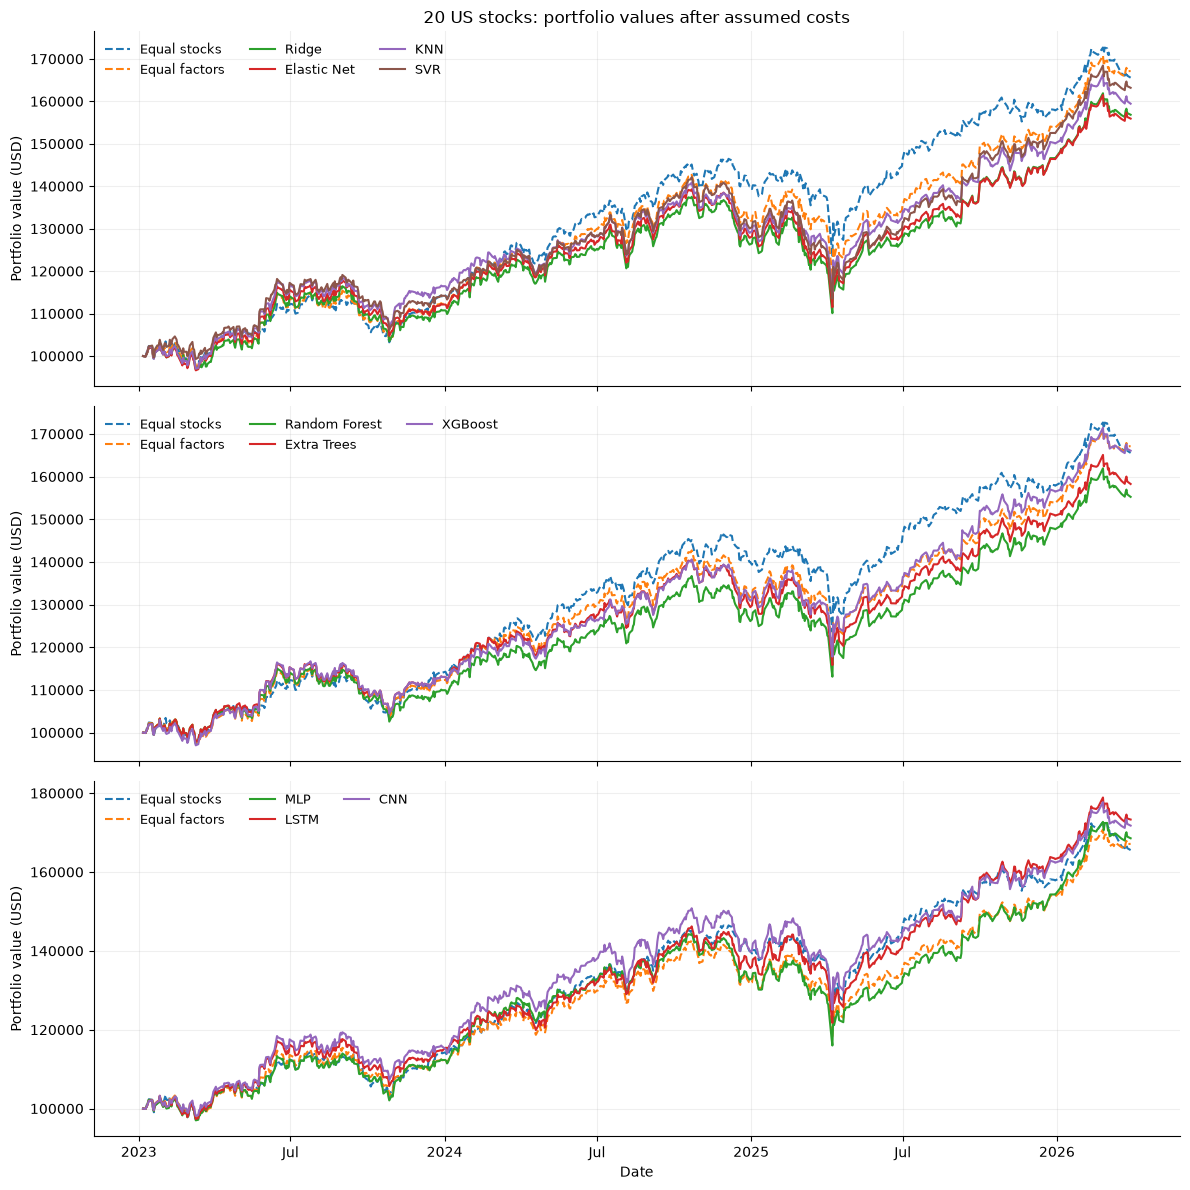

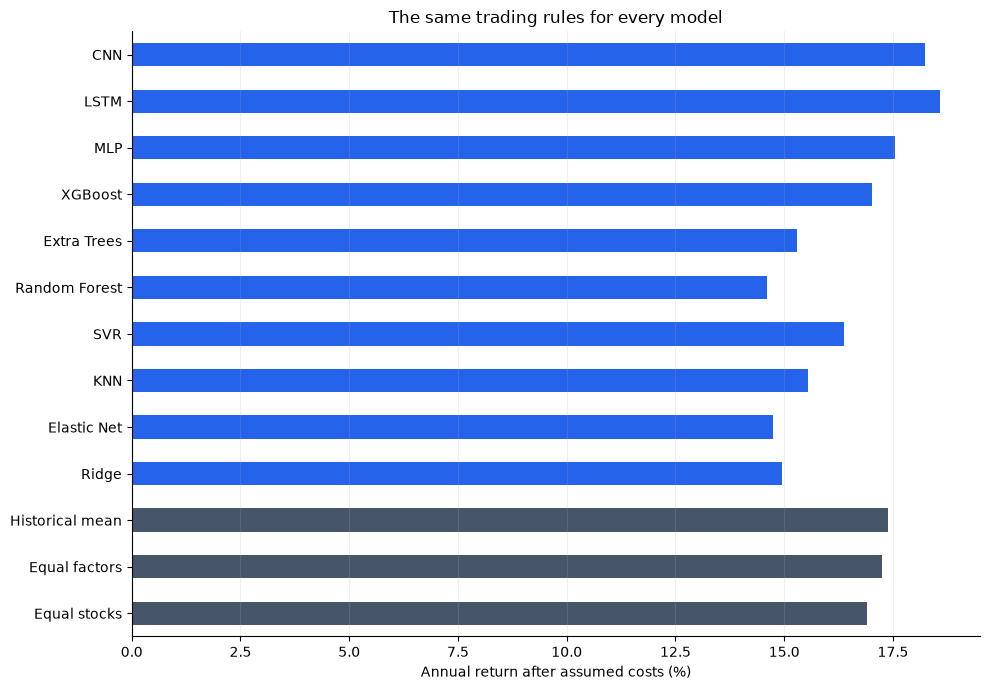

In [13]:
from matplotlib.dates import AutoDateLocator, ConciseDateFormatter

groups = [
    ['Ridge', 'Elastic Net', 'KNN', 'SVR'],
    ['Random Forest', 'Extra Trees', 'XGBoost'],
    ['MLP', 'LSTM', 'CNN']
]
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)
for ax, group in zip(axes, groups):
    for name in ['Equal stocks', 'Equal factors'] + group:
        ax.plot(portfolio_values.index, portfolio_values[name], label=name, linewidth=1.5, linestyle='--' if name in ['Equal stocks', 'Equal factors'] else '-')
    ax.set(ylabel='Portfolio value (USD)')
    ax.grid(alpha=0.2)
    ax.legend(frameon=False, ncol=3, fontsize=9)
locator = AutoDateLocator(minticks=5, maxticks=8)
axes[-1].xaxis.set_major_locator(locator)
axes[-1].xaxis.set_major_formatter(ConciseDateFormatter(locator))
axes[-1].set_xlabel('Date')
axes[0].set_title('20 US stocks: portfolio values after assumed costs')
fig.tight_layout()
fig.savefig(RESULTS / 'portfolio_comparison.png', dpi=160)
plt.show()

fig, ax = plt.subplots(figsize=(10, 7))
performance['Annual return %'].plot.barh(ax=ax, color=['#475569' if n in ['Equal stocks', 'Equal factors', 'Historical mean'] else '#2563eb' for n in performance.index])
ax.set(title='The same trading rules for every model', xlabel='Annual return after assumed costs (%)', ylabel='')
ax.grid(axis='x', alpha=0.2)
fig.tight_layout()
fig.savefig(RESULTS / 'annual_returns.png', dpi=160)
plt.show()

In [14]:
year_rows = []
for year, part in portfolio_values.groupby(portfolio_values.index.year):
    earlier = portfolio_values.loc[portfolio_values.index < part.index[0]]
    starting = earlier.iloc[-1] if len(earlier) else pd.Series(INITIAL_VALUE, index=portfolio_values.columns)
    year_rows.append({'Year': year, 'First date': part.index[0].date(), 'Last date': part.index[-1].date(), **((part.iloc[-1] / starting - 1) * 100).to_dict()})
yearly = pd.DataFrame(year_rows).set_index('Year')
yearly.to_csv(RESULTS / 'yearly_returns.csv')
display(yearly.round(2))

,First date,Last date,Equal stocks,Equal factors,Historical mean,Ridge,Elastic Net,KNN,SVR,Random Forest,Extra Trees,XGBoost,MLP,LSTM,CNN
Year,,,,,,,,,,,,,,,
2023,2023-01-06,2023-12-29,14.0100,12.2500,16.2200,10.7400,12.1300,16.4400,14.1800,9.9200,13.0300,13.0300,12.3100,14.6300,15.7400
2024,2024-01-02,2024-12-31,22.7600,17.3000,16.6700,14.0700,14.1100,10.9000,13.9800,14.7400,14.4900,15.7900,18.2400,18.3300,20.7300
2025,2025-01-02,2025-12-30,12.8000,16.7900,17.9400,16.0300,14.4000,16.2200,17.1900,17.0800,16.5700,19.5500,16.1700,20.3800,16.1900
2026,2026-01-05,2026-03-30,4.8700,8.6800,4.9100,7.0000,6.5300,6.2300,7.0000,5.1300,4.9100,6.1400,9.2600,6.1400,5.8000


The year table shows returns for the dates available in each year. The first and last years may cover only part of a year. We keep them as period returns rather than annualising a short section.

The following table uses the last signal with a full eight-week input window. These are saved historical forecasts, not live trading signals. Missing prices can make this date earlier than the final date in the raw files.

Amazon has a missing week in late April and early May 2026. This breaks the 52-week history needed for later signals, so our completed comparison ends on 30 March 2026. The last usable signal is 17 April. Honeywell's June 2026 spin-off is outside this comparison. We checked its earlier price and share split basis against its company report, but some financial figures were revised later. The saved raw files therefore extend beyond the dates we can use here.

In [15]:
latest = predictions.loc[predictions.signal == sequence_dates[-1], ['signal', 'entry', 'model', 'factor', 'predicted_return', 'trend']].copy()
latest['Predicted return %'] = latest.pop('predicted_return') * 100
latest.to_csv(RESULTS / 'latest_prediction.csv', index=False)
display(latest.set_index(['model', 'factor']).style.format({'Predicted return %': '{:.2f}'}))

The comparison uses the same dates and portfolio rules for every model. Financial statements come from the provider's current historical records and include later revisions. The share counts are estimates, and the group contains companies still trading today. Financial figures enter the calculations after a six-month delay. Factor scores are compared across sectors without sector adjustments. We used one set of model settings and one random seed for this US-stock factor-allocation experiment.

We tested 20 US companies over 42 four-week periods, from 9 January 2023 to 30 March 2026. LSTM produced the highest annualized return among the ten models at 18.57% after the assumed trading costs, followed by CNN at 18.25%. Equal stock weights returned 16.90%, and equal factor weights returned 17.25%. The LSTM portfolio's annualized return was 1.33 percentage points higher than the equal-factor portfolio's in this test. Its forecasts determined which factor received 50%, 30% and 20% at each rebalance. LSTM predicted the direction correctly in 61.90% of factor forecasts, compared with 68.25% for the Always Up comparison, and correctly predicted one of the 40 actual factor declines. Equal stock weights recorded a maximum drawdown of 15.60% and a Sharpe ratio of 1.55. The corresponding LSTM figures were 16.74% and 1.45.